In [27]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from collections import Counter



In [28]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Data transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

Using device: cuda


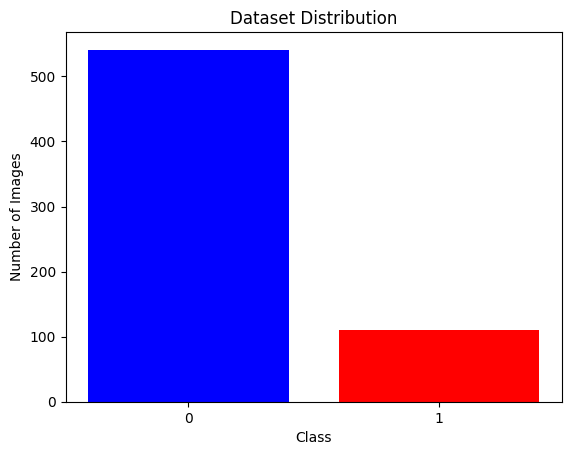

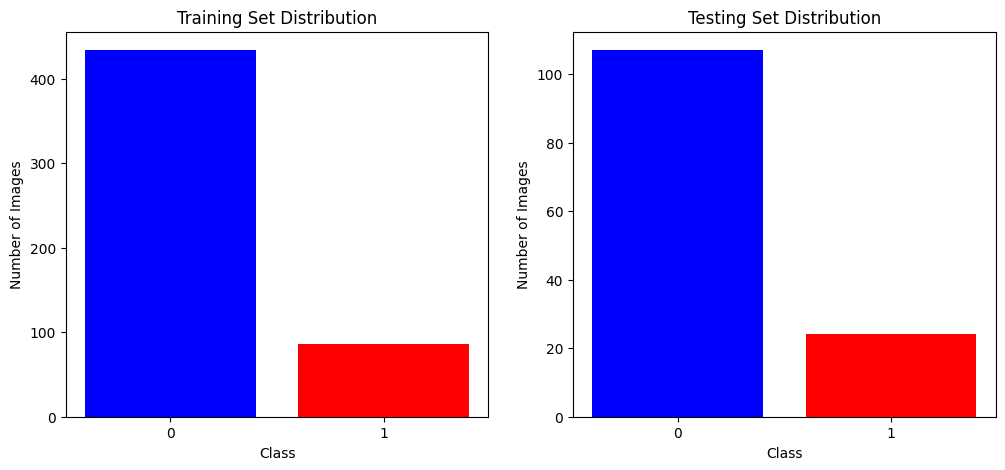

In [29]:
# Download latest version
data_dir = r"C:\Users\RTX\Desktop\newia\fire\Fire-Detection"
dataset = torchvision.datasets.ImageFolder(root=data_dir, transform=transform)

# Count number of images per class
class_counts = Counter([label for _, label in dataset])
class_names = dataset.classes

plt.bar(class_names, [class_counts[i] for i in range(len(class_names))], color=['blue', 'red'])
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Dataset Distribution")
plt.show()

# Split dataset into train and test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size]) 

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Visualize number of images in train and test datasets
train_counts = Counter([label for _, label in train_dataset])
test_counts = Counter([label for _, label in test_dataset])

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].bar(class_names, [train_counts[i] for i in range(len(class_names))], color=['blue', 'red'])
ax[0].set_title("Training Set Distribution")
ax[0].set_xlabel("Class")
ax[0].set_ylabel("Number of Images")

ax[1].bar(class_names, [test_counts[i] for i in range(len(class_names))], color=['blue', 'red'])
ax[1].set_title("Testing Set Distribution")
ax[1].set_xlabel("Class")
ax[1].set_ylabel("Number of Images")

plt.show()

In [30]:
# Define the model
class FireClassifier(nn.Module):
    def __init__(self):
        super(FireClassifier, self).__init__()
        self.model = torchvision.models.resnet18(pretrained=True)
        self.model.fc = nn.Linear(self.model.fc.in_features, 2)  # 2 classes: Fire and No Fire
    
    def forward(self, x):
        return self.model(x)

model = FireClassifier().to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [31]:
# Training function
def train_model(model, train_loader, criterion, optimizer, epochs=10):
    train_losses = []
    train_accuracies = []
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        avg_loss = running_loss / len(train_loader)
        accuracy = 100 * correct / total
        train_losses.append(avg_loss)
        train_accuracies.append(accuracy)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")
    
    return train_losses, train_accuracies

# Train the model
train_losses, train_accuracies = train_model(model, train_loader, criterion, optimizer, epochs=10)


Epoch 1/10, Loss: 0.3632, Accuracy: 85.96%
Epoch 2/10, Loss: 0.2287, Accuracy: 90.58%
Epoch 3/10, Loss: 0.1527, Accuracy: 94.42%
Epoch 4/10, Loss: 0.1879, Accuracy: 94.62%
Epoch 5/10, Loss: 0.1334, Accuracy: 95.38%
Epoch 6/10, Loss: 0.1674, Accuracy: 93.27%
Epoch 7/10, Loss: 0.1074, Accuracy: 95.96%
Epoch 8/10, Loss: 0.0887, Accuracy: 96.54%
Epoch 9/10, Loss: 0.0526, Accuracy: 98.08%
Epoch 10/10, Loss: 0.0775, Accuracy: 96.73%


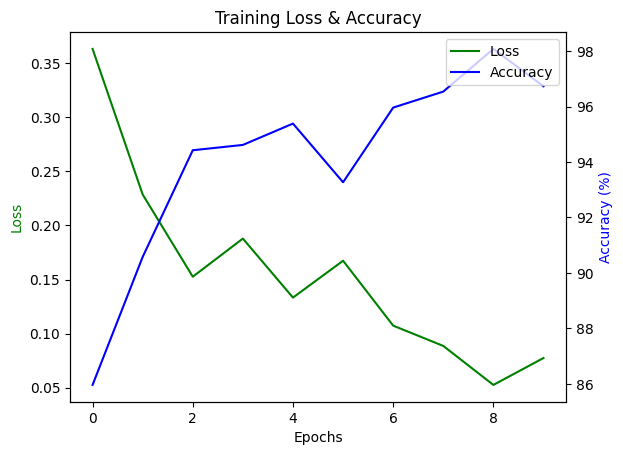

Accuracy: 92.37%


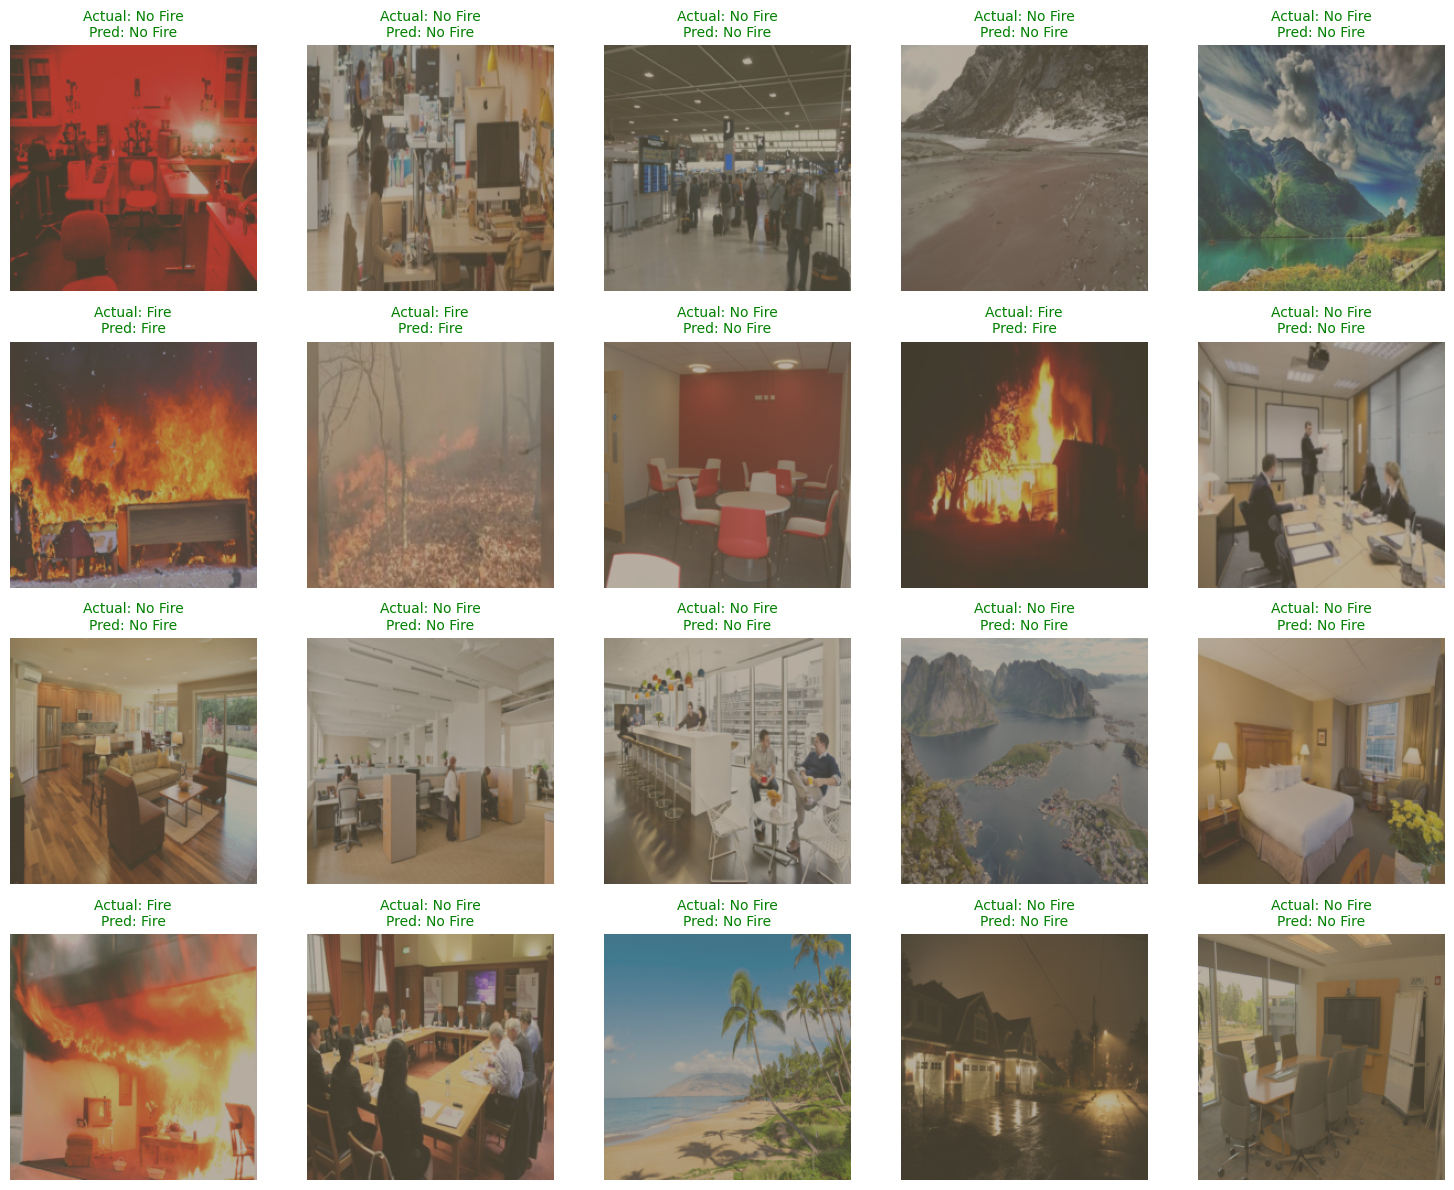

In [39]:
# Plot training loss and accuracy
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(train_losses, 'g-', label='Loss')
ax2.plot(train_accuracies, 'b-', label='Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss', color='g')
ax2.set_ylabel('Accuracy (%)', color='b')
plt.title('Training Loss & Accuracy')
# Add both legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.show()

# Evaluation function
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    all_images = []
    all_labels = []
    all_preds = []
    
    # Define class names
    class_names = {0: 'No Fire', 1: 'Fire'}
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_images.extend(images.cpu())
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
    
    accuracy = 100 * correct / total
    print(f'Accuracy: {accuracy:.2f}%')
    
    # Display 20 images with predictions
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    axes = axes.ravel()
    
    for i in range(20):
        # Properly denormalize the image
        img = all_images[i].permute(1, 2, 0).numpy()
        
        # Assuming images were normalized with mean=[0.485, 0.456, 0.406] and std=[0.229, 0.224, 0.225]
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        
        # Denormalize
        img = std * img + mean
        
        # Clip values to valid range
        img = np.clip(img, 0, 1)
        
        label = all_labels[i]
        pred = all_preds[i]
        color = 'green' if label == pred else 'red'
        
        axes[i].imshow(img)
        axes[i].set_title(f'Actual: {class_names[label]}\nPred: {class_names[pred]}', 
                         color=color, fontsize=10)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return accuracy

# Evaluate the model
test_accuracy = evaluate_model(model, test_loader)